In [20]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os


import seaborn as sns



# Load Data

In [21]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/'

In [22]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster.tsv')

union_cell_info = pd.read_csv(Union_cell_file, sep='\t', index_col=0)

In [49]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [6]:
_total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
_total_frag_per_bc.columns = ['total_fragments']
_total_frag_per_bc.head()

,total_fragments
atac_bc,
AAACAAGCAAACATGT,4
AAACAAGCAAACCAGC,1
AAACAAGCAAACCTAG,207
AAACAAGCAAACTAAC,1
AAACAAGCAAAGAAGC,987


In [1]:
10**4.5 / (10**3.5)

10.0

## Check frag distribution

In [9]:
bc_entropy_list_ST = union_cell_info.index[union_cell_info['_2set_identified_by_atac_ST'] == 'entropy_only' ].to_list()
frag_entropy_sub_ST = frag.loc[
    frag['atac_bc'].isin(bc_entropy_list_ST)
                    ]

bc_tss_list_ST = union_cell_info.index[union_cell_info['_2set_identified_by_atac_ST'] == 'tss_only' ].to_list()
frag_tss_sub_ST = frag.loc[
    frag['atac_bc'].isin(bc_tss_list_ST)
                    ]

bc_common_list_ST = union_cell_info.index[union_cell_info['_2set_identified_by_atac_ST'] == 'both' ].to_list()
frag_common_sub_ST = frag.loc[
    frag['atac_bc'].isin(bc_common_list_ST)
                    ]

In [17]:
bc_entropy_list_SC = union_cell_info.index[union_cell_info['_2set_identified_by_atac_SC'] == 'entropy_only' ].to_list()
frag_entropy_sub_SC = frag.loc[
    frag['atac_bc'].isin(bc_entropy_list_SC)
                    ]   

bc_cr_list_SC = union_cell_info.index[union_cell_info['_2set_identified_by_atac_SC'] == 'cr_only' ].to_list()
frag_cr_sub_SC = frag.loc[
    frag['atac_bc'].isin(bc_cr_list_SC)
                    ]   

bc_common_list_SC = union_cell_info.index[union_cell_info['_2set_identified_by_atac_SC'] == 'both' ].to_list()
frag_common_sub_SC = frag.loc[
    frag['atac_bc'].isin(bc_common_list_SC)
                    ]

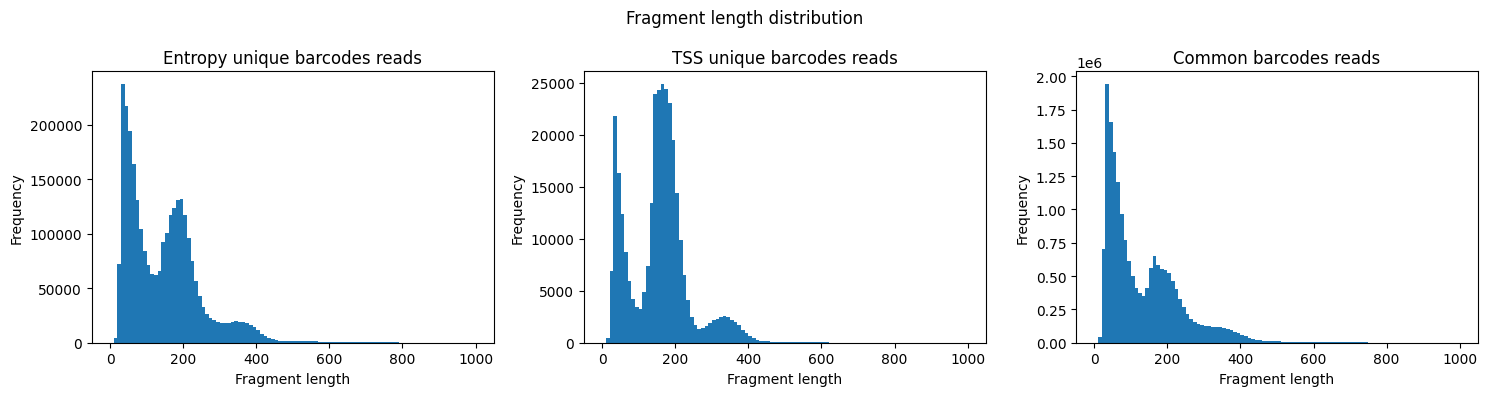

In [16]:
fig, ax = plt.subplots(ncols=3, figsize=(15,4),)
_ = ax[0].hist(frag_entropy_sub_ST['frag_length'], bins=100, range=(0, 1000))
_ = ax[1].hist(frag_tss_sub_ST['frag_length'], bins=100, range=(0, 1000))
_ = ax[2].hist(frag_common_sub_ST['frag_length'], bins=100, range=(0, 1000))

for a in ax:
    a.set_xlabel('Fragment length')
    a.set_ylabel('Frequency')
ax[0].set_title('Entropy unique barcodes reads')
ax[1].set_title('TSS unique barcodes reads')
ax[2].set_title('Common barcodes reads')
fig.suptitle('Fragment length distribution')

plt.tight_layout()

Text(0.5, 0.98, 'Fragment length distribution')

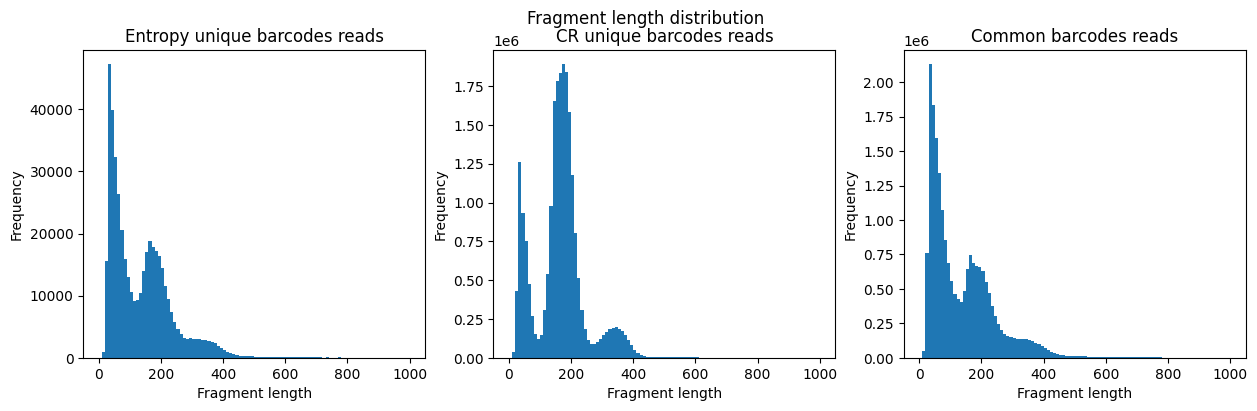

In [19]:
fig, ax = plt.subplots(ncols=3, figsize=(15,4))
_ = ax[0].hist(frag_entropy_sub_SC['frag_length'], bins=100, range=(0, 1000))
_ = ax[1].hist(frag_cr_sub_SC['frag_length'], bins=100, range=(0, 1000))
_ = ax[2].hist(frag_common_sub_SC['frag_length'], bins=100, range=(0, 1000))    
for a in ax:
    a.set_xlabel('Fragment length')
    a.set_ylabel('Frequency')
ax[0].set_title('Entropy unique barcodes reads')
ax[1].set_title('CR unique barcodes reads')
ax[2].set_title('Common barcodes reads')
fig.suptitle('Fragment length distribution')



# To check BCs flagged as DNA-debris by entropy method 

In [58]:
DNA_debris_flag_file = os.path.join(entropy_dir, 'entropy_filtered_bc_w_DNAdebrisflag_df.tsv')
DNA_debris_flag_df = pd.read_csv(DNA_debris_flag_file, sep=',', index_col=0)
DNA_debris_flag_df['atac_bc'] = DNA_debris_flag_df.index.map(lambda x: x.split('-1')[0])
DNA_debris_flag_df.head()

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
TCCTCCATCAGGTTCC-1,0.985064,0.500669,4760,0.105701,0.899693,0.428163,YES,TCCTCCATCAGGTTCC
CAAACAATCAGCCTGT-1,0.977556,1.994810,32956,1.125071,0.324629,0.411986,YES,CAAACAATCAGCCTGT
AGCTTCCAGCTTACTG-1,0.970420,1.741944,28248,0.835721,0.433562,0.399061,YES,AGCTTCCAGCTTACTG
CAACATAAGCAAGGAA-1,0.970204,0.681584,7610,0.165478,0.847489,0.398718,YES,CAACATAAGCAAGGAA


In [55]:
union_cell_info['DNA_debris'] = union_cell_info.index.map(DNA_debris_flag_df[['DNA_debris', 'atac_bc']].set_index('atac_bc')['DNA_debris'])
union_cell_info['DNA_debris'] = union_cell_info['DNA_debris'].fillna('NO')

In [56]:
union_cell_info['DNA_debris'].value_counts()

DNA_debris
NO     2362
YES      22
Name: count, dtype: int64

In [ ]:
union_cell_info.to_csv(os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv'), sep='\t') 
# Save info 